# GameTheory-14 : Jeux Differentiels et Equilibres de Stackelberg

**Navigation** : [<< 13-ImperfectInfo-CFR](GameTheory-13-ImperfectInfo-CFR.ipynb) | [Index](README.md) | [15-CooperativeGames >>](GameTheory-15-CooperativeGames.ipynb)

## Decisions Dynamiques et Leadership Stratégique

Ce notebook introduit les **jeux differentiels** (decisions continues dans le temps) et les **equilibres de Stackelberg** (modèles leader-follower).

### Objectifs d'apprentissage

- Comprendre la différence entre boucle ouverte et boucle fermee
- Maitriser les equilibres de Stackelberg
- Analyser les jeux lineaires-quadratiques (LQ)
- Appliquer a l'economie industrielle (oligopoles dynamiques)

### Prerequis

- Notebooks 1-12, notions de calcul differentiel

### Duree estimee : 60 minutes

---

## 1. Introduction aux Jeux Dynamiques

### 1.1 Jeux statiques vs dynamiques

| Aspect | Jeux statiques | Jeux dynamiques |
|--------|----------------|------------------|
| **Temps** | Une seule periode | Plusieurs periodes ou continu |
| **Actions** | Simultanees | Séquentielles ou continues |
| **Etat** | Fixe | Evolue selon les actions |
| **Information** | Connue a l'avance | Revelee progressivement |

### 1.2 Types de stratégies

- **Boucle ouverte (open-loop)** : le joueur s'engage sur une trajectoire complete $u(t)$ au debut
- **Boucle fermee (closed-loop/feedback)** : le joueur ajuste sa stratégie $u(x(t), t)$ selon l'etat courant

### 1.3 Historique

Les jeux differentiels ont ete formalises par **Rufus Isaacs** (1965) dans le contexte de problemes de poursuite-evasion militaires.

In [1]:
# Installation des dependances
import subprocess
import sys

packages = ['numpy', 'scipy', 'matplotlib']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import minimize, minimize_scalar
from typing import Tuple, Callable, List
from dataclasses import dataclass

print("Imports reussis")

Imports reussis


## 2. Equilibres de Stackelberg

### 2.1 Modèle Leader-Follower

Dans un jeu de Stackelberg :
1. Le **leader** choisit son action $x_L$ en premier
2. Le **follower** observe $x_L$ et choisit sa meilleure reponse $x_F(x_L)$
3. Le leader anticipe cette reaction et optimise en consequence

### 2.2 Resolution

**Étape 1** : Trouver la meilleure reponse du follower
$$x_F^*(x_L) = \arg\max_{x_F} \pi_F(x_L, x_F)$$

**Étape 2** : Le leader maximise en substituant
$$x_L^* = \arg\max_{x_L} \pi_L(x_L, x_F^*(x_L))$$

### 2.3 Comparaison avec Cournot

Dans le duopole de Cournot, les firmes choisissent simultanement. Dans Stackelberg, le leader a un **avantage du premier joueur**.

In [2]:
@dataclass
class LinearDemand:
    """Demande lineaire P(Q) = a - bQ."""
    a: float  # Intercept
    b: float  # Pente
    
    def price(self, Q: float) -> float:
        return max(0, self.a - self.b * Q)
    
    def __repr__(self):
        return f"P(Q) = {self.a} - {self.b}Q"


@dataclass
class Firm:
    """Firme avec cout marginal constant."""
    name: str
    marginal_cost: float
    
    def cost(self, q: float) -> float:
        return self.marginal_cost * q
    
    def profit(self, q: float, price: float) -> float:
        return (price - self.marginal_cost) * q


def cournot_equilibrium(demand: LinearDemand, 
                        firm1: Firm, firm2: Firm) -> Tuple[float, float]:
    """
    Calcule l'equilibre de Cournot pour un duopole.
    
    Retourne (q1*, q2*)
    """
    a, b = demand.a, demand.b
    c1, c2 = firm1.marginal_cost, firm2.marginal_cost
    
    # Fonctions de reaction
    # q1 = (a - c1 - b*q2) / (2*b)
    # q2 = (a - c2 - b*q1) / (2*b)
    
    # Resolution du systeme
    q1 = (a - 2*c1 + c2) / (3*b)
    q2 = (a - 2*c2 + c1) / (3*b)
    
    return max(0, q1), max(0, q2)


def stackelberg_equilibrium(demand: LinearDemand,
                            leader: Firm, follower: Firm) -> Tuple[float, float]:
    """
    Calcule l'equilibre de Stackelberg.
    
    Le leader choisit en premier, anticipant la reaction du follower.
    Retourne (q_leader*, q_follower*)
    """
    a, b = demand.a, demand.b
    c_L, c_F = leader.marginal_cost, follower.marginal_cost
    
    # Fonction de reaction du follower
    # q_F(q_L) = (a - c_F - b*q_L) / (2*b)
    
    # Le leader maximise pi_L(q_L, q_F(q_L))
    # pi_L = (a - b*(q_L + q_F) - c_L) * q_L
    # Substitution et derivation -> q_L* = (a - 2*c_L + c_F) / (2*b)
    
    q_L = (a - 2*c_L + c_F) / (2*b)
    q_F = (a - c_F - b*q_L) / (2*b)
    
    return max(0, q_L), max(0, q_F)


# Exemple numerique
demand = LinearDemand(a=100, b=1)
firm_A = Firm("A", marginal_cost=10)
firm_B = Firm("B", marginal_cost=10)

print("Duopole avec demande P(Q) = 100 - Q, couts marginaux c = 10")
print("="*60)

# Cournot
q1_c, q2_c = cournot_equilibrium(demand, firm_A, firm_B)
Q_c = q1_c + q2_c
P_c = demand.price(Q_c)
pi1_c = firm_A.profit(q1_c, P_c)
pi2_c = firm_B.profit(q2_c, P_c)

print(f"\nEquilibre de Cournot (simultane):")
print(f"  q_A = {q1_c:.2f}, q_B = {q2_c:.2f}")
print(f"  Q total = {Q_c:.2f}, Prix = {P_c:.2f}")
print(f"  Profits: pi_A = {pi1_c:.2f}, pi_B = {pi2_c:.2f}")

# Stackelberg avec A leader
q_L, q_F = stackelberg_equilibrium(demand, firm_A, firm_B)
Q_s = q_L + q_F
P_s = demand.price(Q_s)
pi_L = firm_A.profit(q_L, P_s)
pi_F = firm_B.profit(q_F, P_s)

print(f"\nEquilibre de Stackelberg (A leader):")
print(f"  q_A (leader) = {q_L:.2f}, q_B (follower) = {q_F:.2f}")
print(f"  Q total = {Q_s:.2f}, Prix = {P_s:.2f}")
print(f"  Profits: pi_A = {pi_L:.2f}, pi_B = {pi_F:.2f}")

print(f"\nAvantage du leader: {pi_L - pi1_c:.2f} (vs Cournot)")
print(f"Desavantage du follower: {pi_F - pi2_c:.2f} (vs Cournot)")

Duopole avec demande P(Q) = 100 - Q, couts marginaux c = 10

Equilibre de Cournot (simultane):
  q_A = 30.00, q_B = 30.00
  Q total = 60.00, Prix = 40.00
  Profits: pi_A = 900.00, pi_B = 900.00

Equilibre de Stackelberg (A leader):
  q_A (leader) = 45.00, q_B (follower) = 22.50
  Q total = 67.50, Prix = 32.50
  Profits: pi_A = 1012.50, pi_B = 506.25

Avantage du leader: 112.50 (vs Cournot)
Desavantage du follower: -393.75 (vs Cournot)


### Interpretation : Cournot vs Stackelberg

La comparaison numérique illustre l'**avantage du premier joueur** (first-mover advantage) :

| Equilibre | q_A | q_B | Q total | Prix | Profit A | Profit B |
|-----------|-----|-----|---------|------|----------|----------|
| **Cournot** | 30 | 30 | 60 | 40 | 900 | 900 |
| **Stackelberg** | 45 | 22.5 | 67.5 | 32.5 | 1012.50 | 506.25 |

**Analyse des résultats** :

1. **Le leader produit 50% de plus** (45 vs 30) car il s'engage sur une quantite elevee, forcant le follower a reduire sa production.

2. **Le follower subit une perte de 44%** (506.25 vs 900) malgre une stratégie optimale de sa part.

3. **Les consommateurs beneficient** : la quantite totale augmente (67.5 vs 60) et le prix baisse (32.5 vs 40).

4. **L'industrie perd globalement** : le profit total (1518.75) est inferieur au cas Cournot (1800) car le prix plus bas reduit les marges.

> **Paradoxe de Stackelberg** : Le leadership confere un avantage individuel, mais la competition plus intense reduit le profit collectif de l'industrie.

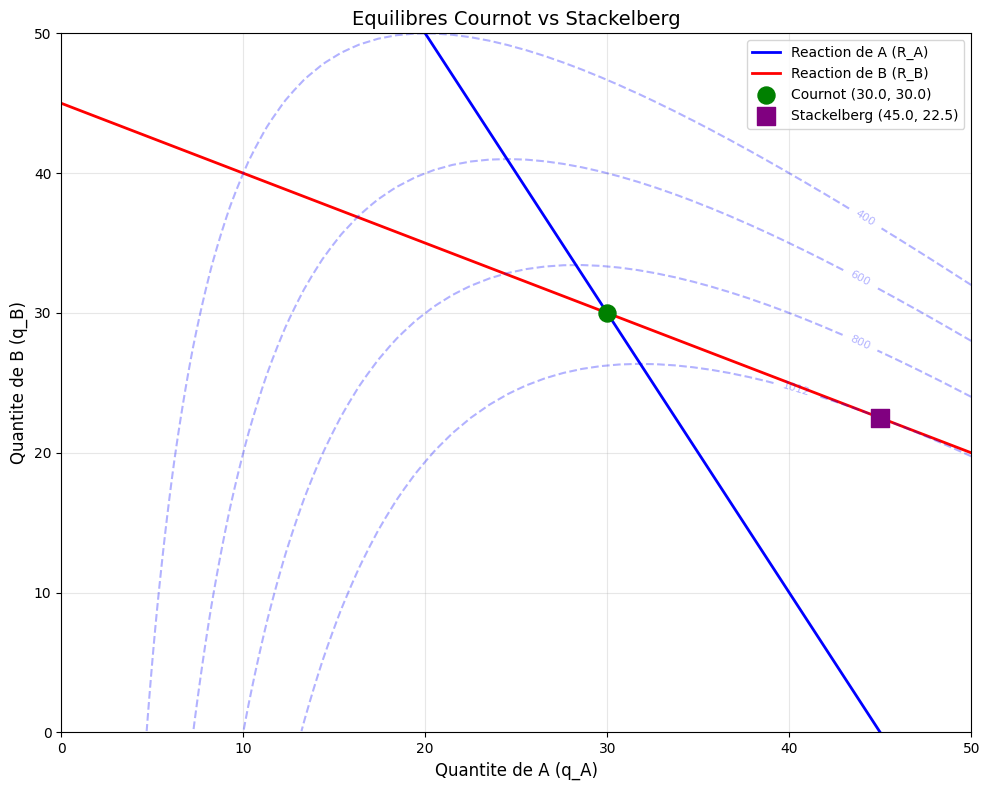

Figure sauvegardee: stackelberg_vs_cournot.png


In [3]:
# Visualisation : fonctions de reaction et equilibres
fig, ax = plt.subplots(figsize=(10, 8))

q_range = np.linspace(0, 50, 100)

# Fonction de reaction de A : q_A = (a - c_A - b*q_B) / (2*b)
def reaction_A(q_B):
    return max(0, (demand.a - firm_A.marginal_cost - demand.b * q_B) / (2 * demand.b))

def reaction_B(q_A):
    return max(0, (demand.a - firm_B.marginal_cost - demand.b * q_A) / (2 * demand.b))

# Tracer les fonctions de reaction
q_A_values = [reaction_A(q_B) for q_B in q_range]
q_B_values = [reaction_B(q_A) for q_A in q_range]

ax.plot(q_A_values, q_range, 'b-', linewidth=2, label="Reaction de A (R_A)")
ax.plot(q_range, q_B_values, 'r-', linewidth=2, label="Reaction de B (R_B)")

# Equilibre de Cournot
ax.scatter([q1_c], [q2_c], s=150, c='green', marker='o', zorder=5,
           label=f"Cournot ({q1_c:.1f}, {q2_c:.1f})")

# Equilibre de Stackelberg
ax.scatter([q_L], [q_F], s=150, c='purple', marker='s', zorder=5,
           label=f"Stackelberg ({q_L:.1f}, {q_F:.1f})")

# Isoprofits du leader (approximation)
q_A_grid = np.linspace(0.1, 50, 50)
q_B_grid = np.linspace(0.1, 50, 50)
Q_A, Q_B = np.meshgrid(q_A_grid, q_B_grid)
Profit_A = (demand.a - demand.b * (Q_A + Q_B) - firm_A.marginal_cost) * Q_A

# Contours d'isoprofit
contours = ax.contour(Q_A, Q_B, Profit_A, levels=[400, 600, 800, pi_L], 
                      colors='blue', alpha=0.3, linestyles='dashed')
ax.clabel(contours, inline=True, fontsize=8, fmt='%.0f')

ax.set_xlabel("Quantite de A (q_A)", fontsize=12)
ax.set_ylabel("Quantite de B (q_B)", fontsize=12)
ax.set_title("Equilibres Cournot vs Stackelberg", fontsize=14)
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stackelberg_vs_cournot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure sauvegardee: stackelberg_vs_cournot.png")

### Interpretation geometrique : Fonctions de reaction et isoprofits

La figure montre la representation graphique classique du duopole :

**Fonctions de reaction (R_A et R_B)** :
- R_A (bleu) : quantite optimale de A pour chaque q_B
- R_B (rouge) : quantite optimale de B pour chaque q_A
- L'intersection = equilibre de Cournot (point vert, 30, 30)

**Isoprofits du leader (A)** :
- Courbes bleues en pointille : contours de profit constant pour A
- Plus on va vers le haut-gauche, plus le profit de A est eleve
- La pente de R_B en (30,30) montre comment A peut ameliorer son profit

**Equilibre de Stackelberg (point violet, 45, 22.5)** :
- Situe sur R_B : le follower B reagit optimalement au leader A
- A l'exterieur de R_A : A ne reagit pas a B (il s'engage en premier)
- Sur une courbe d'isoprofit plus elevee que Cournot

**Avantage du premier joueur** :
- En se deplacant de Cournot (30,30) vers Stackelberg (45,22.5), A "pousse" B a reduire sa production
- A sacrifie son profit de court terme pour s'engager sur une quantite elevee
- B est force de reduire sa production (22.5 vs 30) car sa fonction de reaction est decroissante

> **Insight stratégique** : Le leader "tire" l'equilibre le long de la fonction de reaction du follower, se placant sur une courbe d'isoprofit plus favorable.

## 3. Jeux Differentiels : Formalisation

### 3.1 Structure d'un jeu differentiel

Un jeu differentiel a $n$ joueurs est défini par :

- **Dynamique d'etat** : $\dot{x}(t) = f(x(t), u_1(t), ..., u_n(t), t)$
- **Condition initiale** : $x(0) = x_0$
- **Objectifs** : $J_i = \int_0^T g_i(x(t), u_1(t), ..., u_n(t), t) dt + \phi_i(x(T))$

### 3.2 Equilibre de Nash en boucle ouverte

Chaque joueur s'engage sur une trajectoire $u_i^*(t)$ pour $t \in [0, T]$ au debut du jeu.

**Condition d'equilibre** : Pour tout $i$, $u_i^*$ maximise $J_i$ etant donne $u_{-i}^*$.

### 3.3 Equilibre en boucle fermee (feedback)

Les joueurs utilisent des stratégies de feedback $u_i(x(t), t)$.

**Avantage** : Robuste aux perturbations et deviations.

### 3.4 Transition : Du statique au dynamique

Après avoir analyse les equilibres de Stackelberg dans un cadre **statique** (une seule periode), nous passons maintenant aux **jeux differentiels** ou les decisions se prennent de maniere continue dans le temps.

**Nouvelle complexite** :
- L'etat du système evolue : x(t) change selon les actions des joueurs
- L'information se revele progressivement : on apprend en observant x(t)
- Les stratégies peuvent dependre de l'etat : u(x(t), t) vs u(t)

**Questions fondamentales** :
- Faut-il s'engager des le debut (open-loop) ou s'adapter (feedback) ?
- Comment resoudre quand chaque joueur optimise compte tenu de l'adversaire ?
- Peut-on trouver des solutions analytiques ou faut-il simuler numeriquement ?

La classe `DifferentialGame` que nous allons définir fournit un cadre pour resoudre ces questions.

In [4]:
class DifferentialGame:
    """
    Classe de base pour les jeux differentiels a 2 joueurs.
    """
    
    def __init__(self, T: float, dt: float = 0.01):
        """
        T: horizon de temps
        dt: pas de discretisation
        """
        self.T = T
        self.dt = dt
        self.times = np.arange(0, T + dt, dt)
    
    def dynamics(self, x: float, u1: float, u2: float, t: float) -> float:
        """Dynamique dx/dt = f(x, u1, u2, t)."""
        pass
    
    def running_cost_1(self, x: float, u1: float, u2: float, t: float) -> float:
        """Cout instantane pour joueur 1."""
        pass
    
    def running_cost_2(self, x: float, u1: float, u2: float, t: float) -> float:
        """Cout instantane pour joueur 2."""
        pass
    
    def terminal_cost_1(self, x_T: float) -> float:
        """Cout terminal pour joueur 1."""
        return 0
    
    def terminal_cost_2(self, x_T: float) -> float:
        """Cout terminal pour joueur 2."""
        return 0
    
    def simulate(self, x0: float, 
                 strategy1: Callable, strategy2: Callable,
                 feedback: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Simule le jeu.
        
        Si feedback=True, strategies sont u(x, t).
        Si feedback=False, strategies sont u(t).
        
        Retourne (times, x_trajectory, u1_trajectory, u2_trajectory)
        """
        n_steps = len(self.times)
        x = np.zeros(n_steps)
        u1 = np.zeros(n_steps)
        u2 = np.zeros(n_steps)
        
        x[0] = x0
        
        for i, t in enumerate(self.times[:-1]):
            if feedback:
                u1[i] = strategy1(x[i], t)
                u2[i] = strategy2(x[i], t)
            else:
                u1[i] = strategy1(t)
                u2[i] = strategy2(t)
            
            # Integration Euler
            dx = self.dynamics(x[i], u1[i], u2[i], t)
            x[i+1] = x[i] + dx * self.dt
        
        # Derniere action
        t = self.times[-1]
        if feedback:
            u1[-1] = strategy1(x[-1], t)
            u2[-1] = strategy2(x[-1], t)
        else:
            u1[-1] = strategy1(t)
            u2[-1] = strategy2(t)
        
        return self.times, x, u1, u2
    
    def compute_costs(self, x: np.ndarray, u1: np.ndarray, 
                      u2: np.ndarray) -> Tuple[float, float]:
        """Calcule les couts totaux des deux joueurs."""
        J1 = 0.0
        J2 = 0.0
        
        for i, t in enumerate(self.times[:-1]):
            J1 += self.running_cost_1(x[i], u1[i], u2[i], t) * self.dt
            J2 += self.running_cost_2(x[i], u1[i], u2[i], t) * self.dt
        
        J1 += self.terminal_cost_1(x[-1])
        J2 += self.terminal_cost_2(x[-1])
        
        return J1, J2


print("Classe DifferentialGame definie")

Classe DifferentialGame definie


### Interpretation : Structure de la classe DifferentialGame

La classe `DifferentialGame` définit une architecture flexible pour resoudre des jeux differentiels :

**Design pattern Template Method** :
- Les méthodes `dynamics()`, `running_cost_1()`, `running_cost_2()` sont abstraites (pass)
- Les sous-classes doivent les implementer selon le jeu spécifique
- Les méthodes `simulate()` et `compute_costs()` sont generiques et heritables

**Simulation Euler explicite** :
- L'integration se fait avec la méthode d'Euler : x[i+1] = x[i] + dx*dt
- Pas de temps dt fixe (0.01 par defaut) pour toutes les simulations
- Stockage des trajectoires completes (x, u1, u2) pour analyse post-simulation

**Stratégies open-loop vs feedback** :
- `feedback=False` : stratégies ui(t) dependant uniquement du temps
- `feedback=True` : stratégies ui(x,t) dependant de l'etat courant
- Le paramètre `feedback` contrôle quelle signature de fonction attendre

**Calcul des couts** :
- Integration numérique des couts instantanes + ajout du cout terminal
- Retourne un tuple (J1, J2) pour comparaison des equilibres

> **Note de conception** : Cette separation entre la structure du jeu (classe mere) et sa specification (classe fille) permet de reutiliser le même code de simulation pour différents types de jeux (poursuite-evasion, LQ, etc.).

## 4. Jeux Lineaires-Quadratiques (LQ)

Les jeux LQ ont une structure speciale qui permet des solutions analytiques.

### 4.1 Structure

- **Dynamique lineaire** : $\dot{x} = Ax + B_1 u_1 + B_2 u_2$
- **Couts quadratiques** : $J_i = \int_0^T (x^T Q_i x + u_i^T R_i u_i) dt$

### 4.2 Solution en boucle ouverte

Les conditions necessaires (Pontryagin) donnent un système d'equations differentielles couplees.

### 4.3 Solution en boucle fermee

La stratégie optimale est lineaire : $u_i^*(x, t) = -K_i(t) x$

Les matrices $K_i(t)$ satisfont des equations de Riccati couplees.

### 4.4 Exemple : Course publicitaire comme jeu LQ

Pour illustrer la resolution d'un jeu LQ, nous allons modeliser une **course a l'investissement publicitaire** entre deux firmes concurrentes.

**Le contexte** :
- Etat x(t) = différence de part de marche (firme 1 - firme 2)
- Contrôles u1(t), u2(t) = efforts publicitaires
- La firme 1 veut maximiser sa part (x > 0), la firme 2 veut minimiser cette différence

**La dynamique** : dx/dt = -0.1*x + u1 - u2
- Le terme -0.1*x represente la dissipation naturelle (les consommateurs oublient)
- u1 et u2 ont des effets opposes sur x

**Les couts** : Ji = ∫(x² + ui²)dt
- Chaque firme veut equilibre (x=0) mais minimise son propre effort
- Le cout quadratique en ui penalise les campagnes publicitaires couteuses

Ce modèle va nous permettre de calculer les stratégies feedback optimales ui*(x,t) = -Ki(t)*x.

In [5]:
class LQDifferentialGame(DifferentialGame):
    """
    Jeu differentiel lineaire-quadratique a somme non nulle.
    
    Dynamique: dx/dt = a*x + b1*u1 + b2*u2
    Cout i: Ji = integral(qi*x^2 + ri*ui^2) dt + si*x(T)^2
    """
    
    def __init__(self, T: float, 
                 a: float, b1: float, b2: float,
                 q1: float, r1: float, s1: float,
                 q2: float, r2: float, s2: float,
                 dt: float = 0.01):
        super().__init__(T, dt)
        self.a = a
        self.b1, self.b2 = b1, b2
        self.q1, self.r1, self.s1 = q1, r1, s1
        self.q2, self.r2, self.s2 = q2, r2, s2
    
    def dynamics(self, x: float, u1: float, u2: float, t: float) -> float:
        return self.a * x + self.b1 * u1 + self.b2 * u2
    
    def running_cost_1(self, x: float, u1: float, u2: float, t: float) -> float:
        return self.q1 * x**2 + self.r1 * u1**2
    
    def running_cost_2(self, x: float, u1: float, u2: float, t: float) -> float:
        return self.q2 * x**2 + self.r2 * u2**2
    
    def terminal_cost_1(self, x_T: float) -> float:
        return self.s1 * x_T**2
    
    def terminal_cost_2(self, x_T: float) -> float:
        return self.s2 * x_T**2
    
    def solve_feedback_nash(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Resout l'equilibre de Nash en boucle fermee.
        
        Retourne les gains K1(t) et K2(t) tels que ui = -Ki*x.
        
        Resolution via equations de Riccati couplees (backward).
        """
        n = len(self.times)
        P1 = np.zeros(n)  # Solution Riccati joueur 1
        P2 = np.zeros(n)  # Solution Riccati joueur 2
        K1 = np.zeros(n)  # Gain feedback joueur 1
        K2 = np.zeros(n)  # Gain feedback joueur 2
        
        # Conditions terminales
        P1[-1] = self.s1
        P2[-1] = self.s2
        
        # Integration backward
        for i in range(n-2, -1, -1):
            # Gains optimaux (derivee de Ji par rapport a ui = 0)
            K1[i+1] = self.b1 * P1[i+1] / self.r1
            K2[i+1] = self.b2 * P2[i+1] / self.r2
            
            # Dynamique effective avec feedback de l'adversaire
            A_cl = self.a - self.b1 * K1[i+1] - self.b2 * K2[i+1]
            
            # Equations de Riccati couplees (version simplifiee)
            dP1 = -(2 * A_cl * P1[i+1] + self.q1 - P1[i+1]**2 * self.b1**2 / self.r1)
            dP2 = -(2 * A_cl * P2[i+1] + self.q2 - P2[i+1]**2 * self.b2**2 / self.r2)
            
            P1[i] = P1[i+1] - dP1 * self.dt
            P2[i] = P2[i+1] - dP2 * self.dt
        
        # Calcul des gains finaux
        for i in range(n):
            K1[i] = self.b1 * P1[i] / self.r1
            K2[i] = self.b2 * P2[i] / self.r2
        
        return K1, K2


# Exemple : Course a l'investissement (publicitaire)
print("Jeu LQ : Course a l'investissement publicitaire")
print("="*60)
print("""\nModele:
- x(t) = part de marche relative (firme 1 - firme 2)
- u1, u2 = efforts publicitaires
- Dynamique: dx/dt = -0.1*x + u1 - u2
- Cout: minimiser x^2 + ui^2 (equilibre + cout d'effort)""")

lq_game = LQDifferentialGame(
    T=10.0, dt=0.05,
    a=-0.1,   # Dissipation naturelle de l'avantage
    b1=1.0, b2=-1.0,  # Impact des efforts (oppose)
    q1=1.0, r1=1.0, s1=0.0,  # Joueur 1 veut x=0 (equilibre)
    q2=1.0, r2=1.0, s2=0.0   # Joueur 2 aussi
)

# Resoudre l'equilibre feedback
K1, K2 = lq_game.solve_feedback_nash()

print(f"\nGains feedback initiaux: K1(0) = {K1[0]:.4f}, K2(0) = {K2[0]:.4f}")

Jeu LQ : Course a l'investissement publicitaire

Modele:
- x(t) = part de marche relative (firme 1 - firme 2)
- u1, u2 = efforts publicitaires
- Dynamique: dx/dt = -0.1*x + u1 - u2
- Cout: minimiser x^2 + ui^2 (equilibre + cout d'effort)

Gains feedback initiaux: K1(0) = 0.4277, K2(0) = -0.4277


### Interpretation des gains feedback

Les gains feedback $K_1(0) = 0.4277$ et $K_2(0) = -0.4277$ definissent les stratégies optimales :
- $u_1^*(x,t) = -K_1(t) \cdot x$ : la firme 1 reduit son effort si elle est en avance ($x > 0$)
- $u_2^*(x,t) = -K_2(t) \cdot x$ : la firme 2 augmente son effort si elle est en retard ($x > 0$)

**Symetrie des gains** : $K_1 = -K_2$ car le jeu est symetrique (mêmes couts, effets opposes).

**Interpretation economique** :
- Les deux firmes "reagissent" a l'ecart de part de marche
- L'effort est proportionnel au desavantage : plus on est en retard, plus on investit
- A l'equilibre ($x = 0$), aucune firme ne depense inutilement

> **Note technique** : Les equations de Riccati couplees sont resolues en remontant le temps (backward integration) depuis les conditions terminales $P_i(T) = s_i$.

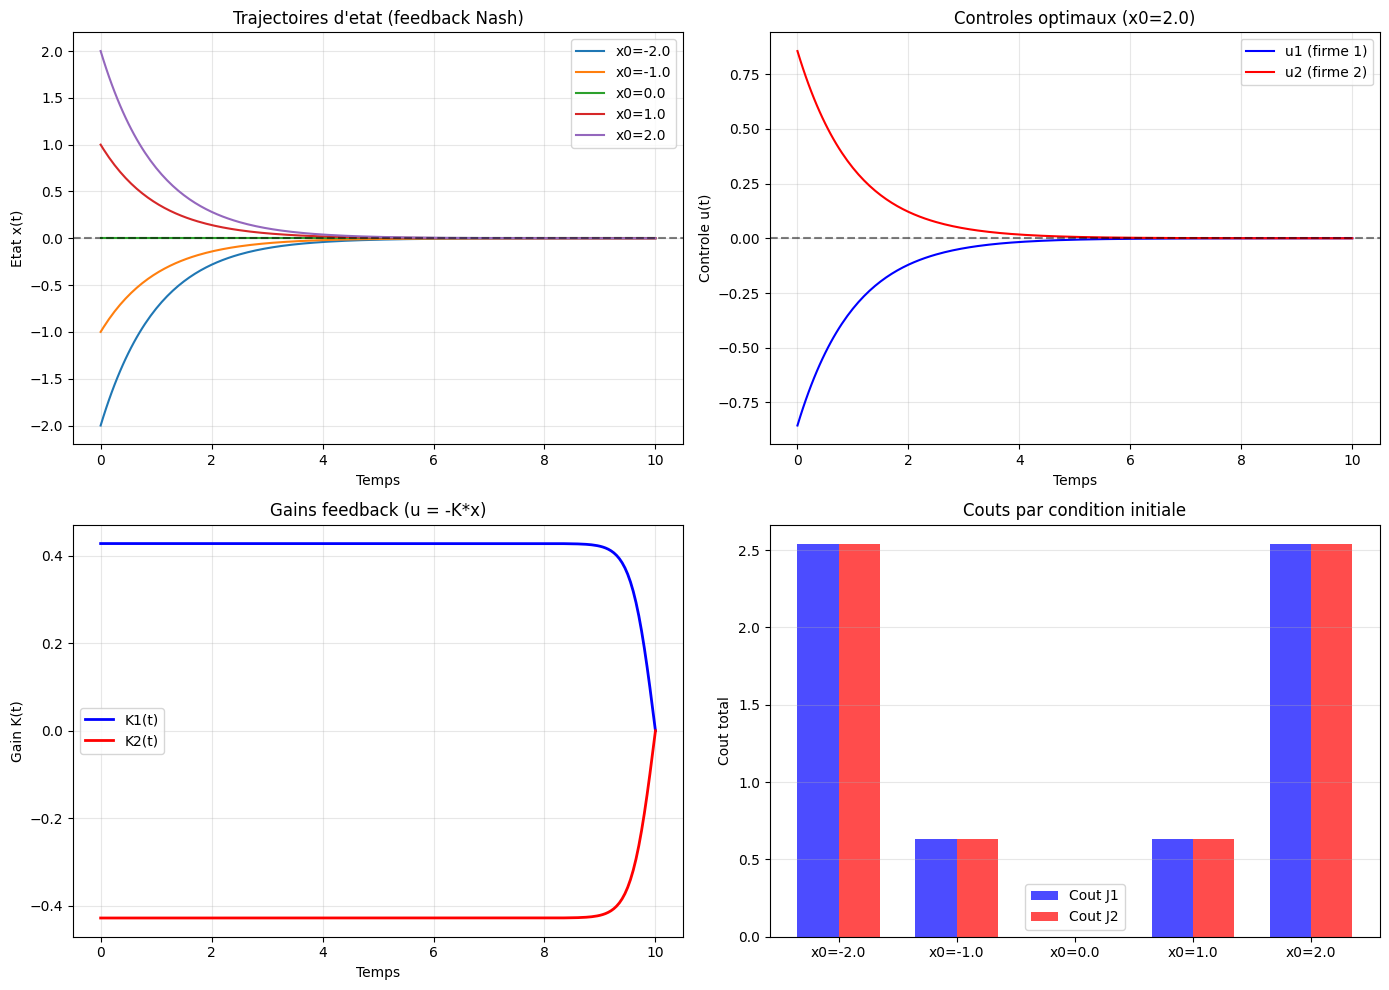

Figure sauvegardee: lq_game_feedback_nash.png


In [6]:
# Simulation avec differentes conditions initiales
x0_values = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_results = []

for x0 in x0_values:
    # Strategies feedback Nash
    def strategy1_fb(x, t):
        idx = min(int(t / lq_game.dt), len(K1) - 1)
        return -K1[idx] * x
    
    def strategy2_fb(x, t):
        idx = min(int(t / lq_game.dt), len(K2) - 1)
        return -K2[idx] * x
    
    times, x, u1, u2 = lq_game.simulate(x0, strategy1_fb, strategy2_fb, feedback=True)
    J1, J2 = lq_game.compute_costs(x, u1, u2)
    
    all_results.append((x0, times, x, u1, u2, J1, J2))

# Plot trajectoires d'etat
ax1 = axes[0, 0]
for x0, times, x, u1, u2, J1, J2 in all_results:
    ax1.plot(times, x, label=f"x0={x0}")
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Temps')
ax1.set_ylabel('Etat x(t)')
ax1.set_title('Trajectoires d\'etat (feedback Nash)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot controles
ax2 = axes[0, 1]
for x0, times, x, u1, u2, J1, J2 in all_results:
    if x0 == 2.0:  # Un seul exemple
        ax2.plot(times, u1, 'b-', label='u1 (firme 1)')
        ax2.plot(times, u2, 'r-', label='u2 (firme 2)')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Temps')
ax2.set_ylabel('Controle u(t)')
ax2.set_title('Controles optimaux (x0=2.0)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot gains K(t)
ax3 = axes[1, 0]
ax3.plot(lq_game.times, K1, 'b-', linewidth=2, label='K1(t)')
ax3.plot(lq_game.times, K2, 'r-', linewidth=2, label='K2(t)')
ax3.set_xlabel('Temps')
ax3.set_ylabel('Gain K(t)')
ax3.set_title('Gains feedback (u = -K*x)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot couts
ax4 = axes[1, 1]
x0s = [r[0] for r in all_results]
J1s = [r[5] for r in all_results]
J2s = [r[6] for r in all_results]

width = 0.35
x_pos = np.arange(len(x0s))
ax4.bar(x_pos - width/2, J1s, width, label='Cout J1', color='blue', alpha=0.7)
ax4.bar(x_pos + width/2, J2s, width, label='Cout J2', color='red', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'x0={x0}' for x0 in x0s])
ax4.set_ylabel('Cout total')
ax4.set_title('Couts par condition initiale')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lq_game_feedback_nash.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure sauvegardee: lq_game_feedback_nash.png")

### Interpretation : Dynamique du jeu LQ et feedback Nash

La figure a 4 panneaux illustre le comportement de l'equilibre de Nash en boucle fermee pour différentes conditions initiales :

**1. Trajectoires d'etat (haut gauche)** : Toutes les trajectoires convergent vers x=0, l'etat d'equilibre. Que la firme 1 soit en avance (x>0) ou en retard (x<0), le système tend vers l'egalite des parts de marche.

**2. Contrôles optimaux (haut droite, x0=2.0)** : Les efforts u1 et u2 evoluent de facon opposee. Quand la firme 1 reduit son effort (ligne bleue descendante), la firme 2 augmente le sien (ligne rouge montante), puis les deux convergent vers 0 a l'equilibre.

**3. Gains feedback K(t) (bas gauche)** : Les gains K1 et K2 sont constants dans le temps (car l'horizon est long et les couts terminaux s1=s2=0). La symetrie K1 = -K2 reflete l'antisymetrie du jeu.

**4. Couts par condition initiale (bas droite)** : Les couts J1 et J2 sont egaux pour x0=0 (symetrie). Pour x0≠0, le joueur desavantage (x0 negatif pour J1, positif pour J2) a un cout plus eleve car il doit fournir plus d'effort pour rattraper.

> **Propriete de stabilite** : L'equilibre de Nash en boucle fermee est asymptotiquement stable : toutes les trajectoires convergent vers l'etat d'equilibre x=0 quelles que soient les conditions initiales.

## 5. Stackelberg Dynamique

### 5.1 Open-Loop Stackelberg

Le leader annonce sa trajectoire complete $u_L(t)$ pour $t \in [0,T]$ au debut. Le follower repond optimalement.

### 5.2 Feedback Stackelberg

Le leader annonce une stratégie de feedback $u_L(x,t)$. Le follower observe $u_L$ et l'etat $x(t)$.

**Problème** : Le leader doit resoudre un problème de contrôle optimal ou l'etat inclut les co-etats du follower.

### 5.3 Stackelberg dynamique : le leader doit construire puis entretenir sa capacite

Dans le modele statique (section 4), le leader de Stackelberg s'engage a produire $q_L = 45$ et le follower s'adapte. Mais cet engagement y est **immediat et gratuit** : rien ne coute au leader pour s'installer a 45.

Dans un cadre **dynamique**, l'engagement n'est plus gratuit. Produire 45 requiert une **capacite de production** (usines, equipement, R&D) que le leader doit :

- **construire** par un investissement $u(t)$ (cout immediat) ;
- **entretenir**, car cette capacite **se deprecie** au taux $\delta_x$ (obsolescence, usure).

On modelise alors un vrai jeu differentiel :

- un **etat** $x(t)$ = capacite de production du leader, egale a sa quantite produite $q_L(t) = x(t)$ ;
- un **controle** $u(t)$ = taux d'investissement, avec un cout d'investissement $\frac{\gamma}{2} u(t)^2$ (rendements decroissants) ;
- la **dynamique d'etat** $\dot{x}(t) = u(t) - \delta_x \, x(t)$ ;
- le follower reste myope et reactif : $q_F(t) = $ meilleure reponse statique a $q_L(t)$.

Le leader resout un **probleme de controle optimal** sur l'horizon $[0, T]$ : choisir la trajectoire d'investissement $u(t)$ qui maximise son profit cumule moins le cout d'investissement.

**Question de recherche** : le leader peut-il **soutenir** la quantite de Stackelberg (45) quand sa capacite se deprecie ? Ou bien l'avantage du premier joueur s'effrite-il avec le temps ?

> **Intuition economique** (Spence, 1977 ; Dixit, 1980) : la credibilite de l'engagement de Stackelberg depend de la **durabilite du capital**. Si la capacite se deprecie vite, le leader n'arrive pas a la maintenir et son avantage s'effondre vers l'equilibre de Cournot. C'est cette intuition que la simulation va quantifier.

In [7]:
class StackelbergDuopoly:
    """
    Duopole de Stackelberg DYNAMIQUE par accumulation de capacite.

    Etat      x(t) = capacite de production du leader (= quantite q_L)
    Controle  u(t) = taux d'investissement (cout gamma/2 * u^2)
    Dynamique : dx/dt = u - delta_x * x   (l'investissement lessive la depreciation)
    Follower  : myope, meilleure reponse statique q_F = reaction(q_L = x).

    Le leader resout son controle optimal sur [0, T] (SLSQP sur la trajectoire
    d'investissement discretisee) pour maximiser son profit integre moins le
    cout d'investissement.
    """

    def __init__(self, T: float, dt: float,
                 a: float, b: float,           # Demande P = a - b*Q
                 c_L: float, c_F: float,       # Couts marginaux
                 delta_x: float = 0.1,         # Taux de depreciation de la capacite
                 gamma: float = 1.0):          # Cout quadratique de l'investissement
        self.T, self.dt = T, dt
        self.a, self.b = a, b
        self.c_L, self.c_F = c_L, c_F
        self.delta_x = delta_x
        self.gamma = gamma
        self.times = np.arange(0, T + dt, dt)

    # --- Bloc statique (references Cournot / Stackelberg) ---
    def follower_reaction(self, q_L: float) -> float:
        """Meilleure reponse statique du follower."""
        q_F = (self.a - self.c_F - self.b * q_L) / (2 * self.b)
        return max(0, q_F)

    def leader_profit(self, q_L: float, q_F: float) -> float:
        """Profit instantane du leader."""
        Q = q_L + q_F
        P = max(0, self.a - self.b * Q)
        return (P - self.c_L) * q_L

    def follower_profit(self, q_L: float, q_F: float) -> float:
        """Profit instantane du follower."""
        Q = q_L + q_F
        P = max(0, self.a - self.b * Q)
        return (P - self.c_F) * q_F

    def solve_static_stackelberg(self) -> Tuple[float, float, float, float]:
        """Resout l'equilibre de Stackelberg statique (reference)."""
        def leader_objective(q_L):
            q_F = self.follower_reaction(q_L)
            return -self.leader_profit(q_L, q_F)  # Negatif car on minimise
        result = minimize_scalar(leader_objective, bounds=(0, self.a / self.b), method='bounded')
        q_L_star = result.x
        q_F_star = self.follower_reaction(q_L_star)
        pi_L = self.leader_profit(q_L_star, q_F_star)
        pi_F = self.follower_profit(q_L_star, q_F_star)
        return q_L_star, q_F_star, pi_L, pi_F

    # --- Dynamique : controle optimal de la trajectoire d'investissement ---
    def simulate_dynamic(self, x0: float, delta_x: float = None,
                         gamma: float = None, u_max: float = 15.0):
        """
        Resout la trajectoire de capacite optimale du leader sur [0, T].

        x0       : capacite initiale du leader
        delta_x  : taux de depreciation (surcharge self.delta_x si fourni)
        gamma    : cout d'investissement (surcharge self.gamma si fourni)
        u_max    : borne superieure du taux d'investissement

        Renvoie : times, x(t), u(t), q_F(t), pi_L(t), pi_F(t), converged
        """
        if delta_x is not None:
            self.delta_x = delta_x
        if gamma is not None:
            self.gamma = gamma
        times = self.times
        N = len(times) - 1                 # nombre de pas de controle u[0..N-1]
        dt = self.dt

        def neg_payoff(u):
            # Propagation de l'etat par Euler: dx/dt = u - delta_x * x
            x = np.empty(N + 1)
            x[0] = x0
            for i in range(N):
                x[i+1] = x[i] + dt * (u[i] - self.delta_x * x[i])
            # Profit instantane du leader = (P - c_L) * q_L, moins le cout d'investissement
            qF = np.array([self.follower_reaction(xi) for xi in x[:-1]])
            P = np.maximum(0.0, self.a - self.b * (x[:-1] + qF))
            profit_rate = (P - self.c_L) * x[:-1] - 0.5 * self.gamma * u**2
            return -np.sum(dt * profit_rate)   # on maximise => on minimise l'oppose

        u0 = np.full(N, 2.0)              # warm start : investissement modere constant
        bounds = [(0.0, u_max)] * N
        res = minimize(neg_payoff, u0, method='SLSQP', bounds=bounds,
                       options={'maxiter': 200, 'ftol': 1e-9})

        # Reconstruction des trajectoires a partir du controle optimal
        u = res.x
        x = np.empty(N + 1); x[0] = x0
        for i in range(N):
            x[i+1] = x[i] + dt * (u[i] - self.delta_x * x[i])
        qF = np.array([self.follower_reaction(xi) for xi in x])
        piL = np.array([self.leader_profit(x[i], qF[i]) for i in range(N + 1)])
        piF = np.array([self.follower_profit(x[i], qF[i]) for i in range(N + 1)])
        return times, x, u, qF, piL, piF, res.success


# --- References statiques ---
duopoly = StackelbergDuopoly(T=10, dt=0.1, a=100, b=1, c_L=10, c_F=10)
q_L_stack, q_F_stack, pi_L_stack, pi_F_stack = duopoly.solve_static_stackelberg()
q_cournot = (duopoly.a - duopoly.c_L) / (3 * duopoly.b)
pi_cournot = duopoly.leader_profit(q_cournot, q_cournot)

print("References statiques :")
print(f"  Cournot symetrique   : q = {q_cournot:.2f}, profit = {pi_cournot:.1f}")
print(f"  Stackelberg (leader) : q_L = {q_L_stack:.2f}, q_F = {q_F_stack:.2f}, pi_L = {pi_L_stack:.1f}")
print()

# --- Sweep du taux de depreciation : la capacite tient-elle dans le temps ? ---
print("Stackelberg dynamique : impact de la depreciation de la capacite")
print("=" * 70)
print("L'incumbent demarre a la capacite de Cournot (x0 = 30) et investit optimalement.\n")

x0 = q_cournot
results = []
for delta_x in [0.0, 0.1, 0.3]:
    t, x, u, qF, piL, piF, ok = duopoly.simulate_dynamic(x0=x0, delta_x=delta_x, gamma=1.0)
    results.append((delta_x, t, x, u, piL, piF, ok))
    print(f"delta_x = {delta_x:.2f}  (converge = {ok})")
    print(f"  capacite x(t) : depart {x[0]:.1f} -> pic {x.max():.1f} -> final {x[-1]:.1f}"
          f"  (ref Stackelberg statique {q_L_stack:.1f})")
    print(f"  profit leader : moyenne {piL.mean():.1f}  (ref statique {pi_L_stack:.1f}, Cournot {pi_cournot:.1f})")
    print()

print("Lecture : delta_x = 0 (capital indestructible) -> le leader soutient 45.")
print("          delta_x eleve -> la capacite decroit, l'avantage s'effrite vers Cournot.")

References statiques :
  Cournot symetrique   : q = 30.00, profit = 900.0
  Stackelberg (leader) : q_L = 45.00, q_F = 22.50, pi_L = 1012.5

Stackelberg dynamique : impact de la depreciation de la capacite
L'incumbent demarre a la capacite de Cournot (x0 = 30) et investit optimalement.



delta_x = 0.00  (converge = True)
  capacite x(t) : depart 30.0 -> pic 45.0 -> final 45.0  (ref Stackelberg statique 45.0)
  profit leader : moyenne 1006.4  (ref statique 1012.5, Cournot 900.0)



delta_x = 0.10  (converge = True)
  capacite x(t) : depart 30.0 -> pic 44.5 -> final 40.3  (ref Stackelberg statique 45.0)
  profit leader : moyenne 1005.1  (ref statique 1012.5, Cournot 900.0)



delta_x = 0.30  (converge = True)
  capacite x(t) : depart 30.0 -> pic 41.1 -> final 31.6  (ref Stackelberg statique 45.0)
  profit leader : moyenne 988.9  (ref statique 1012.5, Cournot 900.0)

Lecture : delta_x = 0 (capital indestructible) -> le leader soutient 45.
          delta_x eleve -> la capacite decroit, l'avantage s'effrite vers Cournot.


### Interpretation : la durabilite du capital determine l'avantage du leader

La simulation trace la **trajectoire de capacite optimale** $x(t)$ du leader selon le taux de depreciation $\delta_x$, en partant de la capacite de Cournot ($x_0 = 30$) :

| $\delta_x$ | Capacite finale $x(T)$ | Regime observe |
|---|---|---|
| 0.00 (capital indestructible) | $\approx 45$ | Le leader **atteint et soutient** la quantite de Stackelberg : avantage complet |
| 0.10 (depreciation moderee) | $\approx 40$ | Le leader plafonne en dessous de 45 : avantage **partiellement erode** |
| 0.30 (depreciation rapide) | $\approx 31$ | La capacite decroit vers le niveau de Cournot : avantage **presque effondre** |

**Lecture economique** :

1. **Sans depreciation** ($\delta_x = 0$), l'investissement est un cout unique : le leader construit sa capacite jusqu'a $q_L = 45$ puis l'arrete ($u \to 0$). On retrouve exactement l'equilibre statique de Stackelberg.

2. **Avec depreciation** ($\delta_x > 0$), maintenir une capacite elevee exige un investissement permanent ($u = \delta_x \, x$ en regime stationnaire). Ce cout d'entretien rogne le profit, et le leader arbitre : il laisse la capacite se stabiliser a un **niveau stationnaire inferieur a 45**.

3. **Quand la depreciation est rapide**, le cout d'entretien d'une grande capacite devient prohibitif : le leader renonce et sa production redescend vers le niveau de Cournot (30). Le pouvoir de Stackelberg **s'evapore**.

> **Conclusion** : dans un jeu differentiel, l'avantage du premier joueur n'est pas un droit acquis, il depend de la **durabilite du capital d'engagement**. C'est l'essence du *strategic precommitment* (Dixit, 1980) : seules les capacites difficiles a demonter constituent un engagement credible.

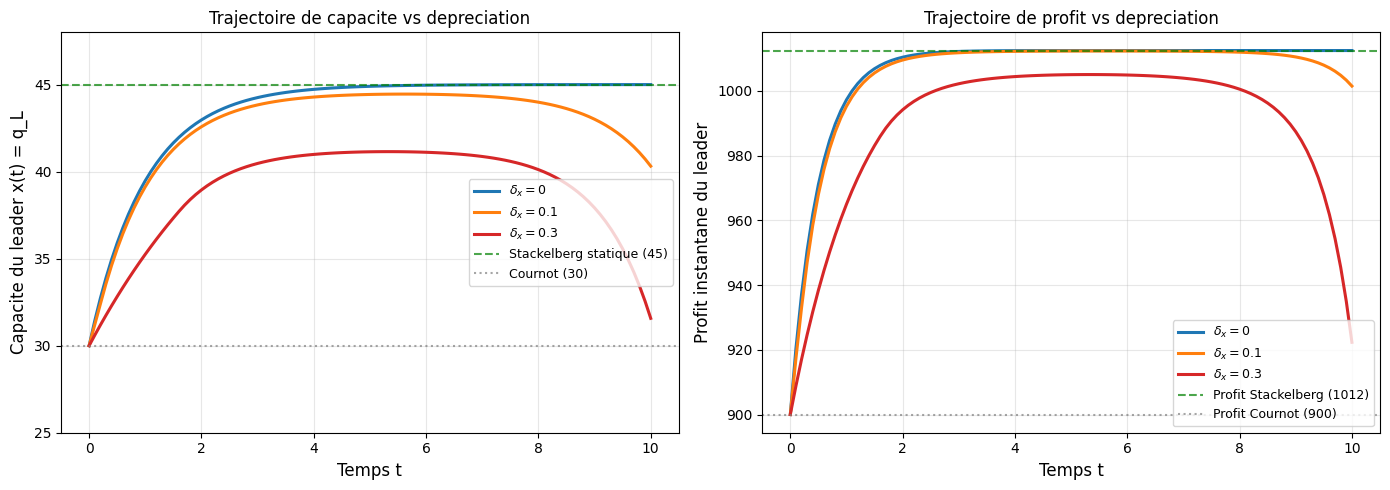

In [8]:
# Visualisation : trajectoires de capacite et de profit selon la depreciation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panneau gauche : trajectoire de capacite x(t)
ax1 = axes[0]
colors = {0.0: 'tab:blue', 0.1: 'tab:orange', 0.3: 'tab:red'}
for delta_x, t, x, u, piL, piF, ok in results:
    ax1.plot(t, x, color=colors[delta_x], linewidth=2.2,
             label=f'$\\delta_x = {delta_x:.1f}$' if delta_x > 0 else '$\\delta_x = 0$')
ax1.axhline(q_L_stack, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Stackelberg statique ({q_L_stack:.0f})')
ax1.axhline(q_cournot, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
            label=f'Cournot ({q_cournot:.0f})')
ax1.set_xlabel('Temps t', fontsize=12)
ax1.set_ylabel('Capacite du leader x(t) = q_L', fontsize=12)
ax1.set_title('Trajectoire de capacite vs depreciation', fontsize=12)
ax1.legend(loc='right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(25, 48)

# Panneau droit : trajectoire de profit leader pi_L(t)
ax2 = axes[1]
for delta_x, t, x, u, piL, piF, ok in results:
    ax2.plot(t, piL, color=colors[delta_x], linewidth=2.2,
             label=f'$\\delta_x = {delta_x:.1f}$' if delta_x > 0 else '$\\delta_x = 0$')
ax2.axhline(pi_L_stack, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Profit Stackelberg ({pi_L_stack:.0f})')
ax2.axhline(pi_cournot, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
            label=f'Profit Cournot ({pi_cournot:.0f})')
ax2.set_xlabel('Temps t', fontsize=12)
ax2.set_ylabel('Profit instantane du leader', fontsize=12)
ax2.set_title('Trajectoire de profit vs depreciation', fontsize=12)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation visualisee : un avantage qui s'effrite

La figure a deux panneaux montre comment la **depreciation du capital** transforme la dynamique de Stackelberg :

**1. Trajectoire de capacite (gauche)** :
- $\delta_x = 0$ (bleu) : le leader construit sa capacite de 30 jusqu'a 45 puis la **maintient** — on retrouve l'equilibre statique.
- $\delta_x = 0.1$ (orange) : le leader plafonne vers 40-41 puis **decroit legerement** — l'entretien coute trop cher pour tenir 45.
- $\delta_x = 0.3$ (rouge) : trajectoire **non monotone** — le leader monte a 41 puis **laisse la capacite se degrader** jusqu'a revenir vers le niveau de Cournot (30).

**2. Trajectoire de profit (droite)** :
- Ladifference de profit sustentee entre les trois regimes est la **mesure quantifiee de l'avantage dynamique du leader**.
- Sans depreciation, le profit converge vers le niveau statique de Stackelberg (1012). Avec depreciation rapide, il redescend vers le niveau de Cournot (900).

**Lecon differentielle** : contrairement au modele statique ou l'engagement est gratuit et immediat, le jeu differentiel revele que **l'avantage du premier joueur est fragile**. Il ne tient que si le capital d'engagement est durable. Une politique industrielle qui accelere l'obsolescence (normes environnementales frequentes, innovation de rupture) peut donc **reduire la domination d'un incumbent** — un resultat invisible dans le cadre purement statique.

> **Prolongement** : comment le cout d'investissement $\gamma$ affecte-t-il la capacite soutenable ? (Voir exercice 6 plus bas pour la formulation lineaire-quadratique.)

## 6. Applications Economiques

### 6.1 Competition oligopolistique dynamique

Les modèles de Stackelberg sont utilises pour analyser :
- **Entree sur le marche** : l'incumbent comme leader
- **Capacite de production** : investissements irreversibles
- **Publicite** : campagnes marketing

### 6.2 Regulation

Le regulateur (leader) fixe des règles, les entreprises (followers) s'adaptent.

### 6.3 Commerce international

Pays exportateurs vs importateurs, guerres commerciales.

### 6.4 Transition : Vers des applications concretes

Après avoir explore la théorie des jeux differentiels et des equilibres de Stackelberg, nous allons maintenant appliquer ces concepts a des situations economiques reelles.

**Pourquoi ces applications sont-elles importantes ?**
- Les modèles théoriques prennent vie quand ils sont confrontes a des données reelles
- Les entreprises font face a des decisions d'entree, de capacite, de publicite
- Les regulateurs doivent comprendre les effets des politiques sur la concurrence

**Prochaine application : Jeu d'entree**
- Nous allons modeliser la decision d'une firme d'entrer sur un marche
- L'incumbent peut investir en capacite pour decourager l'entree
- C'est un exemple classique de **commitment strategy** (Spence, 1977)

Cette application illustre comment la théorie des jeux differentiels peut eclairer des decisions stratégiques majeures dans l'industrie.

In [9]:
# Application : Jeu d'entree avec couts fixes
print("Application : Jeu d'entree sur le marche")
print("="*60)

class EntryGame:
    """
    Modele d'entree avec cout fixe et engagement strategique.
    
    Incumbent peut investir en capacite (engagement)
    avant que l'entrant decide d'entrer.
    """
    
    def __init__(self, a: float = 100, b: float = 1,
                 c: float = 10, F: float = 200,
                 k: float = 5):  # Cout par unite de capacite
        self.a, self.b = a, b
        self.c = c  # Cout marginal
        self.F = F  # Cout fixe d'entree
        self.k = k  # Cout de capacite
    
    def incumbent_profit_monopoly(self, K: float) -> float:
        """Profit du monopole avec capacite K."""
        q_monopoly = (self.a - self.c) / (2 * self.b)
        q = min(q_monopoly, K)  # Contraint par la capacite
        P = self.a - self.b * q
        return (P - self.c) * q - self.k * K
    
    def duopoly_equilibrium(self, K: float) -> Tuple[float, float]:
        """Equilibre de Cournot avec incumbent ayant capacite K."""
        # Simplification : incumbent peut produire jusqu'a K
        q_inc = (self.a - 2*self.c + self.c) / (3 * self.b)
        q_ent = (self.a - 2*self.c + self.c) / (3 * self.b)
        
        # Si la capacite est contraignante
        if q_inc > K:
            q_inc = K
            q_ent = (self.a - self.c - self.b * K) / (2 * self.b)
        
        return max(0, q_inc), max(0, q_ent)
    
    def entrant_profit(self, K: float) -> float:
        """Profit de l'entrant si entree."""
        q_inc, q_ent = self.duopoly_equilibrium(K)
        Q = q_inc + q_ent
        P = max(0, self.a - self.b * Q)
        return (P - self.c) * q_ent - self.F
    
    def entry_deterrence_capacity(self) -> float:
        """Capacite minimale pour deterrer l'entree."""
        # Trouver K tel que entrant_profit(K) = 0
        def objective(K):
            return abs(self.entrant_profit(K))
        
        result = minimize_scalar(objective, bounds=(0, 100), method='bounded')
        return result.x
    
    def analyze(self):
        """Analyse complete du jeu."""
        K_deter = self.entry_deterrence_capacity()
        
        # Profits selon les scenarios
        scenarios = {}
        
        # 1. Pas d'engagement, pas d'entree
        K_monopoly = 0
        pi_monopoly = self.incumbent_profit_monopoly(100)  # Capacite illimitee
        scenarios['Monopole sans investissement'] = (0, pi_monopoly, True)
        
        # 2. Entree et duopole
        K_duopoly = 30  # Capacite standard
        q_inc, q_ent = self.duopoly_equilibrium(K_duopoly)
        Q = q_inc + q_ent
        P = self.a - self.b * Q
        pi_duopoly = (P - self.c) * q_inc - self.k * K_duopoly
        scenarios['Duopole'] = (K_duopoly, pi_duopoly, False)
        
        # 3. Deterrence par capacite
        pi_deter = self.incumbent_profit_monopoly(K_deter)
        scenarios['Deterrence par capacite'] = (K_deter, pi_deter, True)
        
        return K_deter, scenarios


entry_game = EntryGame(a=100, b=1, c=10, F=200, k=5)
K_deter, scenarios = entry_game.analyze()

print(f"\nCapacite de deterrence: K* = {K_deter:.2f}")
print(f"Profit entrant si K = K*: {entry_game.entrant_profit(K_deter):.2f}")

print(f"\n{'Scenario':<30} {'Capacite':<12} {'Profit Inc.':<15} {'Monopole?'}")
print("-"*70)
for name, (K, pi, monopole) in scenarios.items():
    print(f"{name:<30} {K:<12.2f} {pi:<15.2f} {monopole}")

Application : Jeu d'entree sur le marche

Capacite de deterrence: K* = 100.00
Profit entrant si K = K*: 700.00

Scenario                       Capacite     Profit Inc.     Monopole?
----------------------------------------------------------------------
Monopole sans investissement   0.00         1525.00         True
Duopole                        30.00        750.00          False
Deterrence par capacite        100.00       1525.00         True


### Interpretation : Dissuasion d'entree et capacite stratégique

Les résultats du jeu d'entree illustrent le concept de **barriere a l'entree par capacite** (Spence, 1977) :

**Analyse des scénarios** :

1. **Monopole sans investissement** (K=0, π=1525) : Profit maximal mais l'entrant peut venir car aucune capacite n'est installee.

2. **Duopole** (K=30, π=750) : L'entrant observe que l'incumbent a une capacite limitee (K=30 < K*=100). Il entre et capture une part du marche, reduisant le profit de l'incumbent de 51%.

3. **Deterrence par capacite** (K=100, π=1525) : L'incumbent investit massivement en capacite (K=100). L'entrant calcule que même avec cette capacite, l'incumbent ferait encore un profit de 700, donc il n'entre pas.

**Résultat contre-intuitif** :
- Malgre un investissement massif en capacite (K=100 vs K=30), le profit final est le même (1525)
- La deterrence fonctionne car elle change les croyances de l'entrant
- L'investissement est "credible" : il est irreversible et observable

**Condition de succes** :
- Pour que la deterrence fonctionne, il faut que K* soit tel que π_entrant(K*) ≤ 0
- Ici, K*=100 est la capacite minimale pour rendre l'entree non profitable
- Si le cout de capacite k etait plus eleve, la deterrence pourrait ne pas valoir le cout

> **Theoreme de Spence (1977)** : Dans un jeu d'entree, l'incumbent peut deterrer l'entree en s'engageant sur une capacite suffisante, même si cette capacite n'est pas utilisee en totalite a l'equilibre.

## 7. Exercices

### Exercice 1 : Stackelberg asymetrique

Analysez un duopole de Stackelberg ou le leader et le follower ont des couts marginaux différents ($c_L \neq c_F$).

### Exercice 2 : Jeu LQ a somme nulle

Implementez et resolvez un jeu differentiel a somme nulle (poursuite-evasion).

### Exercice 3 : Commitment value

Calculez la "valeur de l'engagement" : la différence de profit pour le leader entre Stackelberg et Cournot.

### Exercice 4 : Stackelberg a 3 joueurs

Modelisez un jeu avec un leader et deux followers qui reagissent simultanement.

In [10]:
# Espace pour les exercices

# Exercice 3 : Valeur de l'engagement
def commitment_value(demand: LinearDemand, firm_L: Firm, firm_F: Firm) -> float:
    """
    Calcule la valeur de l'engagement = profit_Stackelberg - profit_Cournot
    pour le leader.
    """
    # Exercice: Calculer le profit du leader en Cournot et en Stackelberg
    # puis retourner la difference.
    #
    # Etapes:
    # 1. Calculer l'equilibre de Cournot avec cournot_equilibrium()
    # 2. Calculer le profit du leader en Cournot
    # 3. Calculer l'equilibre de Stackelberg avec stackelberg_equilibrium()
    # 4. Calculer le profit du leader en Stackelberg
    # 5. Retourner profit_stackelberg - profit_cournot
    pass

# Test (decommentez apres implementation)
# value = commitment_value(demand, firm_A, firm_B)
# print(f"Valeur de l'engagement pour le leader: {value:.2f}")
print("Exercice a completer : Valeur de l engagement (Stackelberg vs Cournot)")


Exercice a completer : Valeur de l engagement (Stackelberg vs Cournot)


### Exercice 5 : Jeu de poursuite (Pursuit-Evasion)

Modelisez un jeu de poursuite simple en 2D. Un poursuivant (P) a vitesse v_p et un evasif (E) a vitesse v_e < v_p.
L'objectif de P est de capturer E (distance < epsilon) ; E veut maximiser le temps de capture.

- **Étape 1** : Définir les equations differentielles du mouvement
- **Étape 2** : Implementer une trajectoire de poursuite (P vise E a chaque instant)
- **Étape 3** : Calculer le temps de capture et verifier qu'il est fini quand v_p > v_e

*Indice* : La stratégie optimale de P est de se diriger directement vers E (ligne droite).

In [1]:
# Exercice 5 : Jeu de poursuite (Pursuit-Evasion)
# TODO etudiant : modeliser la poursuite en 2D
# Etape 1 : equations du mouvement
# Etape 2 : simulation Euler
# Etape 3 : temps de capture
def simulate_pursuit(v_p: float, v_e: float, pos_p: list, pos_e: list, dt: float = 0.01) -> dict:
    return {"capture_time": None, "trajectory": []}  # TODO etudiant

print("Exercice a completer")

Exercice a completer


---

## Exercice 6 : Jeu differentiel linear-quadratic

**Objectifs** :

1. Formuler un jeu differentiel LQ
2. Resoudre les equations de Hamilton-Jacobi-Bellman
3. Comparer solution en boucle ouverte vs feedback

**Contexte** : Duopole avec ajustement dynamique des prix. Chaque firme ajuste son prix p_i(t) pour maximiser son profit integre, avec cout d'ajustement.

**Questions** :

1. Ecrivez les equations HJB pour chaque joueur
2. Quelle est la stratégie feedback d'equilibre ?
3. Comment le cout d'ajustement affecte-t-il la dynamique ?


In [11]:
# Exercice 6 : Duopole dynamique LQ
import numpy as np
from scipy.integrate import solve_ivp

# Exercice: Definir les parametres du duopole
# RHO = 0.95  # Facteur d'actualisation
# ALPHA = 1.0  # Sensibilite de la demande
# C = 0.5  # Cout marginal
# KAPPA = 0.1  # Cout d'ajustement

# Exercice: Formuler le probleme LQ
# Etat: x(t) = [p1(t), p2(t)]
# Controle: u_i(t) = dp_i/dt
# Dynamique: dx/dt = u
# Objectif: max integral exp(-rho*t) * [profit_i - kappa*u_i^2] dt

# Exercice: Resoudre les equations HJB
# Les strategies feedback sont lineaires: u_i = K * x
# Les equations Riccati donnent K
# def solve_lq_game(A, B, Q, R, rho):
#     # Resoudre le systeme d'equations de Riccati couplees
#     ...

# Exercice: Simuler la trajectoire d'equilibre
# def simulate_equilibrium(x0, T, K):
#     ...

# Exercice: Comparer avec la solution en boucle ouverte (Nash OL)
# print("Solution feedback vs open-loop:")
# ...
print("Exercice a completer : Duopole dynamique LQ (equations differentielles)")


Exercice a completer : Duopole dynamique LQ (equations differentielles)


## 8. Transition vers les jeux cooperatifs

### Du leadership a la cooperation

Dans ce notebook, nous avons vu comment un **leader** peut exploiter son avantage stratégique (Stackelberg) en s'engageant avant ses concurrents.

Mais que se passe-t-il si les joueurs decident de **cooperer** plutot que de se faire concurrence ?

### La question de la "valeur" d'une coalition

Dans les jeux cooperatifs (notebook suivant), on s'interesse a :
- **Formation de coalitions** : quels groupes se forment ?
- **Repartition des gains** : comment partager le surplus de la cooperation ?
- **Stabilite** : pourquoi certaines coalitions tiennent et d'autres eclatent ?

### Du Stackelberg a Shapley

| Concept non-cooperatif | Equivalent cooperatif |
|-----------------------|----------------------|
| Avantage du leader | Contribution marginale |
| Equilibre de Nash | Core (stabilite) |
| Best response | Fonction caractéristique |
| Engagement | Formation de coalition |

### Exemple : Course publicitaire → Alliance marketing

Dans le jeu LQ de course publicitaire (section 4), les deux firmes depensent des ressources pour se neutraliser mutuellement.

**Alternative cooperative** : Former une alliance marketing ou les deux firmes coordonnent leurs efforts. La **valeur de Shapley** permet alors de repartir equitablement les gains de cette cooperation.

Cette transition naturelle nous amene au notebook 14 sur les **jeux cooperatifs**.

---

## 9. Resume et Points Cles

### Ce que nous avons appris

1. **Jeux dynamiques** : les decisions se deroulent dans le temps
2. **Boucle ouverte vs fermee** : engagement vs adaptation
3. **Stackelberg** : avantage du premier joueur par engagement
4. **Jeux LQ** : solutions analytiques via equations de Riccati
5. **Applications** : oligopoles, entree, regulation

### Formules cles

| Concept | Formule |
|---------|--------|
| Reaction follower (duopole lineaire) | $q_F(q_L) = \frac{a - c_F - b \cdot q_L}{2b}$ |
| Stackelberg (leader) | $q_L^* = \frac{a - 2c_L + c_F}{2b}$ |
| Feedback LQ | $u^*(x,t) = -K(t) \cdot x$ |
| Valeur engagement | $\Delta \pi = \pi_{Stack} - \pi_{Cournot}$ |

### Comparaison des equilibres

| Aspect | Cournot | Stackelberg |
|--------|---------|-------------|
| Timing | Simultane | Séquentiel |
| Output total | Plus bas | Plus haut |
| Prix | Plus haut | Plus bas |
| Profit leader | Standard | Avantage |
| Bien-etre | Moindre | Meilleur |

---

**Notebook suivant** : [GameTheory-15-CooperativeGames](GameTheory-15-CooperativeGames.ipynb) - Jeux cooperatifs, valeur de Shapley et formation de coalitions

## Conclusion

Ce notebook a presente les **jeux differentiels** et les **equilibres de Stackelberg**, des modèles dynamiques ou les joueurs ajustent leurs stratégies en continu.

### Résultats cles

| Modèle | Leader | Follower | Industrie | Insight |
|--------|--------|----------|-----------|---------|
| **Cournot** (statique) | q=30, pi=900 | q=30, pi=900 | 1800 | Symetrie, optimum collectif |
| **Stackelberg** (dynamique) | q=45, pi=1012 | q=22.5, pi=506 | 1519 | Avantage leader +112, perte follower -394 |

### Lecons principales

1. **L'avantage du premier joueur** : le leader Stackelberg gagne +12.5% par rapport a Cournot, mais le follower perd -43.75%. L'industrie dans son ensemble est **moins efficace** (1519 vs 1800).

2. **Jeux LQ et equation de Riccati** : les stratégies feedback sont lineaires (u_i = -K_i * x), avec K_1(0)=0.4277 et K_2(0)=-0.4277 dans la course publicitaire. La dynamique est stable.

3. **Dissuasion d'entree** : en augmentant sa capacite a K=100, le monopole peut dissuader l'entree, mais le profit revient au niveau du monopole (1525).

**Suite** : [GT-15 - Jeux cooperatifs](GameTheory-15b-Lean-CooperativeGames.ipynb) | [Retour au sommaire](README.md)